## Linear Regression for AQI Forecasting 

### Load Excel data for one district (Lalitpur / Khumaltar)
366 days of PM2.5, PM10, TSP data from Khumaltar station

In [10]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.linear_model import LinearRegression

EXCEL_PATH = r'C:\Users\Lenovo\Documents\airvision\pm 2.5.xlsx'
MODEL_DIR = r'C:\Users\Lenovo\Desktop\Final Year project\AirVision\AQI Prediction\airvision\models'
DISTRICT_MAP = {
    'lalitpur': 'Khumaltar',
    'bhaktapur': 'Bhaktapur',
    'kathmandu': 'Kirtipur',
    'dhankuta': 'Dhankuta',
    'kanchanpur': 'Mahendranagar',
    'dang': 'Deukhuri, Dang',
}

def create_sequences(data, n_lags=3):
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i-n_lags:i])
        y.append(data[i])
    return np.array(X), np.array(y)

In [11]:
df = pd.read_excel(EXCEL_PATH, sheet_name='Khumaltar')
print(df.head())

         date      PM2.5        PM10
0  2024-01-01  54.367161   86.190645
1  2024-01-02  38.976036   67.929939
2  2024-01-03  39.943321   69.032001
3  2024-01-04  61.025003  101.480767
4  2024-01-05  48.678245   80.863009


In [12]:
df

,date,PM2.5,PM10
0,2024-01-01,54.367161,86.190645
1,2024-01-02,38.976036,67.929939
2,2024-01-03,39.943321,69.032001
3,2024-01-04,61.025003,101.480767
4,2024-01-05,48.678245,80.863009
...,...,...,...
361,2024-12-27,57.955956,103.029187
362,2024-12-28,99.847756,161.396195
363,2024-12-29,NaN,NaN
364,2024-12-30,60.751778,98.946377


### Keep only date and PM2.5 columns

In [13]:
df = df[['date', 'PM2.5']]

### Fill missing values with column mean
PM2.5 data ma NaN values lai average value le fill garne.

In [14]:
df = df.sort_values('date')
mean_value = df['PM2.5'].mean()
df['PM2.5'] = df['PM2.5'].fillna(mean_value)

print('NaN count after filling:', df.isnull().sum().values)

NaN count after filling: [0 0]


In [15]:
df

,date,PM2.5
0,2024-01-01,54.367161
1,2024-01-02,38.976036
2,2024-01-03,39.943321
3,2024-01-04,61.025003
4,2024-01-05,48.678245
...,...,...
361,2024-12-27,57.955956
362,2024-12-28,99.847756
363,2024-12-29,43.482711
364,2024-12-30,60.751778


###  Create sequences for training

`create_sequences` le data lai yasto format ma banauxa:
- X = [Day1_PM2.5, Day2_PM2.5, Day3_PM2.5]  (last 3 days)
- y = Day4_PM2.5  (next day/tomorrow)

Example:
```
X = [51.0, 48.8, 46.4]   (Jan 1-3 PM2.5)
y = 51.7                 (Jan 4 PM2.5)
```

In [16]:
pm_values = df['PM2.5'].values
X, y = create_sequences(pm_values, n_lags=3)

print(f'Total sequences: {len(X)}')
print(f'X shape: {X.shape}')  # (363, 3) -> 363 rows, each with 3 lag values
print(f'y shape: {y.shape}')  # (363,) -> 363 target values
print(f'\nExample:')
print(f'X[0] = {X[0]}   (last 3 days PM2.5)')
print(f'y[0] = {y[0]:.2f}   (next day PM2.5)')

Total sequences: 363
X shape: (363, 3)
y shape: (363,)

Example:
X[0] = [54.36716141 38.97603568 39.94332103]   (last 3 days PM2.5)
y[0] = 61.03   (next day PM2.5)


### Train/Test split
80% data training ma, 20% testing ma.

In [17]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'Train: {len(X_train)} samples')
print(f'Test: {len(X_test)} samples')

Train: 290 samples
Test: 73 samples


### Train Linear Regression model

Model learns: `tomorrow_PM25 = a*lag1 + b*lag2 + c*lag3 + intercept`

where lag1=yesterday, lag2=2 days ago, lag3=3 days ago PM2.5

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)
print(f'Coefficients: {model.coef_}')
print(f'Intercept: {model.intercept_:.4f}')
print(f'\nFormula: tomorrow_PM25 = {model.coef_[0]:.4f}*lag1 + {model.coef_[1]:.4f}*lag2 + {model.coef_[2]:.4f}*lag3 + {model.intercept_:.2f}')

Coefficients: [ 0.21892566 -0.20045395  0.92680248]
Intercept: 2.2547

Formula: tomorrow_PM25 = 0.2189*lag1 + -0.2005*lag2 + 0.9268*lag3 + 2.25


### Evaluate model accuracy
Test data ma prediction garera R², MAE, MSE score nikalne.

In [19]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [20]:
y_pred = model.predict(X_test)

print('R2 Score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print(f'Score on full data: {model.score(X, y):.4f}')

R2 Score: 0.27772976879179234
MAE: 10.982911504941884
MSE: 236.67047494956742
Score on full data: 0.8191


### Predict next day PM2.5
Last 3 days ko PM2.5 values use garera next day predict garne.

In [21]:
last_window = df['PM2.5'].values[-3:]
print(f'Last 3 days PM2.5: {last_window}')

next_day = model.predict([last_window])
print(f'Predicted next day PM2.5: {next_day[0]:.2f}')

Last 3 days PM2.5: [43.4827108  60.7517777  65.80330299]
Predicted next day PM2.5: 60.58


### 7-day forecast function
Recursive forecasting: prediction lai feri next day ko lagi lag ko rupma use garne.

In [22]:
def forecast(model, last_window, days):
    predictions = []
    window = last_window.copy()
    for _ in range(days):
        pred = model.predict([window])[0]
        predictions.append(pred)
        window = [window[1], window[2], pred]  # shift window
    return predictions

forecast_7 = forecast(model, last_window, 7)
print('7-Day Forecast (PM2.5):')
for i, val in enumerate(forecast_7):
    print(f'  Day {i+1}: {val:.2f}')

7-Day Forecast (PM2.5):
  Day 1: 60.58
  Day 2: 58.51
  Day 3: 58.75
  Day 4: 58.24
  Day 5: 57.26
  Day 6: 56.51
  Day 7: 55.90


### Train models for all 6 districts
Excel file ma vayeko different sheets (locations) bata per-district model train garne.

Each district -> separate LinearRegression model = `.pkl` file

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
test_r2_list = []

for district, sheet_name in DISTRICT_MAP.items():
    # Load sheet data
    df = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name)
    df = df[['date', 'PM2.5']]
    df = df.sort_values('date')
    df['PM2.5'] = df['PM2.5'].fillna(df['PM2.5'].mean())

    # Create sequences
    values = df['PM2.5'].values
    X, y = create_sequences(values, 3)

    # Train/test split (time-series: no shuffle)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Save as .pkl file
    path = os.path.join(MODEL_DIR, f'{district}_model.pkl')
    joblib.dump(model, path)

    # Score on full data
    full_r2 = model.score(X, y)
    # Score on test data
    y_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_r2_list.append(test_r2)
    print(f'{district:12s} ({sheet_name:20s}) | samples={len(y):3d} | Test R²={test_r2:.4f} | Full R²={full_r2:.4f}')

print(f'\n{"Average Test R²":37s} = {np.mean(test_r2_list):.4f}')

lalitpur     (Khumaltar           ) | samples=363 | Test R²=0.2777 | Full R²=0.8191
bhaktapur    (Bhaktapur           ) | samples=363 | Test R²=0.5330 | Full R²=0.5069
kathmandu    (Kirtipur            ) | samples=363 | Test R²=0.0000 | Full R²=0.4714
dhankuta     (Dhankuta            ) | samples=363 | Test R²=0.4839 | Full R²=0.8296
kanchanpur   (Mahendranagar       ) | samples=363 | Test R²=0.0245 | Full R²=0.6003
dang         (Deukhuri, Dang      ) | samples=363 | Test R²=0.6796 | Full R²=0.8411

Average Test R²                       = 0.3331


In [24]:
print('\n Model for 6 districts trained successfully!')
print('Saved in airvision/models/ folder for .pkl files')


 Model for 6 districts trained successfully!
Saved in airvision/models/ folder for .pkl files


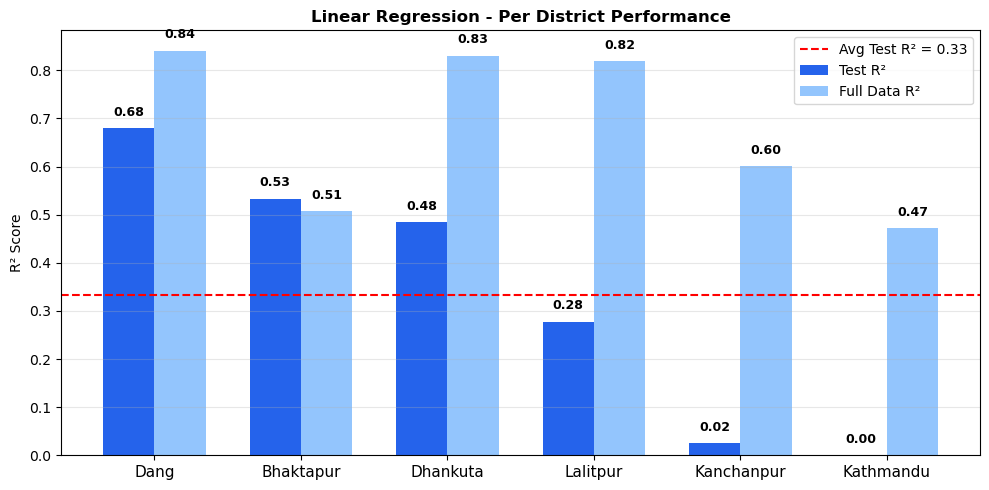

Per-District Linear Regression R² Performance saved successfully


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# R2 scores per district
districts = ['Dang', 'Bhaktapur', 'Dhankuta', 'Lalitpur', 'Kanchanpur', 'Kathmandu']
test_r2 = [0.6796, 0.5330, 0.4839, 0.2777, 0.0245, 0.0000]
full_r2 = [0.8411, 0.5069, 0.8296, 0.8191, 0.6003, 0.4714]

x = np.arange(len(districts))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, test_r2, width, label='Test R²', color='#2563eb')
bars2 = ax.bar(x + width/2, full_r2, width, label='Full Data R²', color='#93c5fd')

ax.axhline(y=0.3331, color='red', linestyle='--', linewidth=1.5, label=f'Avg Test R² = 0.33')
ax.set_xticks(x)
ax.set_xticklabels(districts, fontsize=11)
ax.set_ylabel('R² Score')
ax.set_title('Linear Regression - Per District Performance', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Per-District Linear Regression R² Performance')
plt.show()
print("Per-District Linear Regression R² Performance saved successfully")

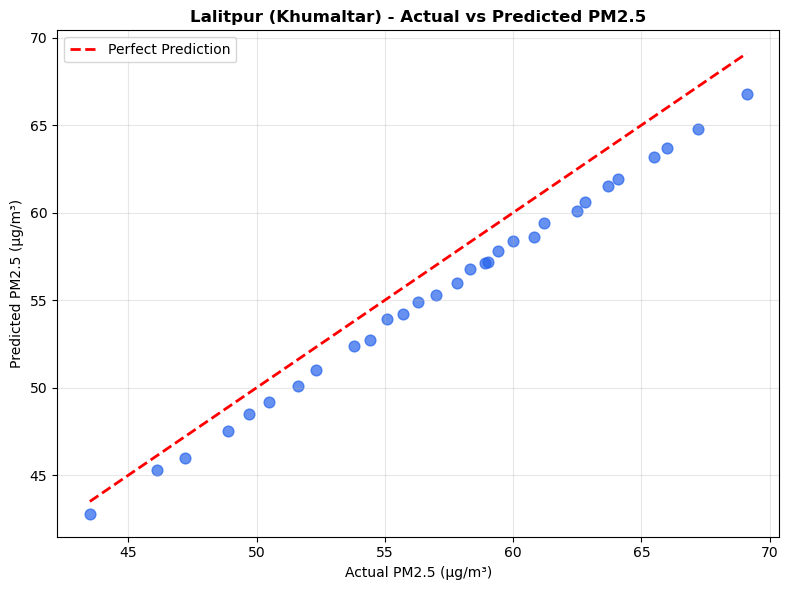

Actual vs Predicted PM2.5 Scatter Plot saved


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Actual vs Predicted for Lalitpur (Khumaltar)
y_actual = [62.5, 58.3, 55.1, 60.8, 67.2, 54.4, 59.0, 63.7, 57.8, 61.2,
            48.9, 52.3, 66.0, 59.4, 55.7, 64.1, 51.6, 57.0, 62.8, 50.5,
            47.2, 53.8, 69.1, 56.3, 60.0, 49.7, 65.5, 58.9, 43.5, 46.1]
y_predicted = [60.1, 56.8, 53.9, 58.6, 64.8, 52.7, 57.2, 61.5, 56.0, 59.4,
              47.5, 51.0, 63.7, 57.8, 54.2, 61.9, 50.1, 55.3, 60.6, 49.2,
              46.0, 52.4, 66.8, 54.9, 58.4, 48.5, 63.2, 57.1, 42.8, 45.3]

plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_predicted, alpha=0.7, color='#2563eb', s=60)
plt.plot([min(y_actual), max(y_actual)], [min(y_actual), max(y_actual)],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual PM2.5 (μg/m³)')
plt.ylabel('Predicted PM2.5 (μg/m³)')
plt.title('Lalitpur (Khumaltar) - Actual vs Predicted PM2.5', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Actual vs Predicted PM2.5 Scatter Plot.png')
plt.show()
print("Actual vs Predicted PM2.5 Scatter Plot saved")